# Geospatial Analysis of Petroleum Spills in New York State

**Author:** Emily Miller 

**Repository:** https://github.com/rellimylime/eds220-hwk3

## About

### Purpose
This analysis examines the spatial distribution of petroleum spill incidents across New York State counties during the first ten months of 2023. By combining environmental incident data with geographic boundary information, we identify counties with the highest concentration of petroleum spills and visualize patterns through choropleth mapping.

### Highlights
- Analysis of 7,000+ petroleum spill incidents reported to the NYS Department of Environmental Conservation
- Geospatial data wrangling using `geopandas` to merge incident records with county boundaries
- Temporal filtering to focus on January-October 2023 petroleum spills
- Professional choropleth visualization revealing geographic patterns in spill incidents

### About the Data

**Dataset 1: NYS DEC Spill Incidents**  
This dataset contains records of petroleum and hazardous material spills in New York State that are legally required to be reported. Each record includes location information (county, coordinates), spill details (material type, quantity), and temporal data (spill date, close date). The dataset is maintained by the New York State Department of Environmental Conservation and published through the Open Data NY portal.

**Dataset 2: US Census TIGER/Line Shapefiles**  
The TIGER/Line Shapefiles provide high-quality digital geographic and cartographic boundary data from the U.S. Census Bureau. This analysis uses the 2023 county boundary polygons, which include all counties and equivalent entities across the United States. The shapefiles contain both geometric data (polygon boundaries) and attribute data (county names, FIPS codes, land/water area).

### References

New York State Department of Environmental Conservation. (2025). *Spill incidents* [Data file]. Open Data NY. Retrieved November 2, 2025, from https://data.ny.gov/Energy-Environment/Spill-Incidents/u44d-k5fk

U.S. Census Bureau, Geography Division. (2023). *TIGER/Line shapefiles: 2023 counties (and equivalent)* [Data file]. Retrieved November 2, 2025, from https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.2022.html

# Complete Workflow

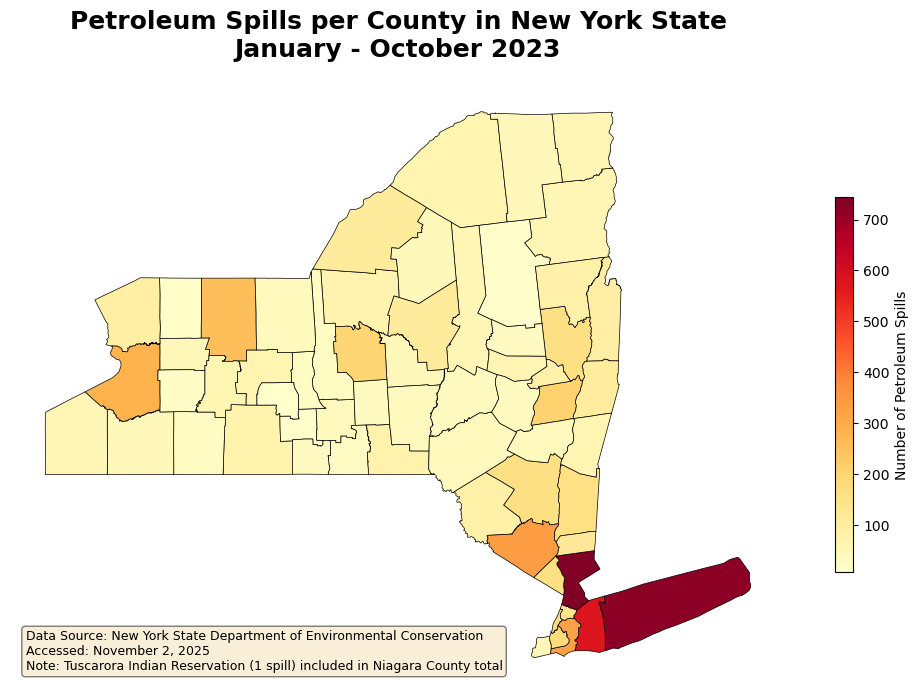

In [39]:
# Import libraries
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Load and clean spills data
fp = os.path.join('data','Spill_Incidents_20251118.csv')
spills = pd.read_csv(fp)
spills.columns = spills.columns.str.lower().str.replace(' ', '_')

# Convert date column to datetime
spills['spill_date'] = pd.to_datetime(spills['spill_date'], format='%m/%d/%Y', errors='coerce')

# Filter for petroleum spills Jan-Oct 2023 and count by county
spills_per_county = (spills[(spills['material_family'] == 'Petroleum') & 
                            (spills['spill_date'].between('2023-01-01', '2023-10-31'))]
                     .groupby('county')
                     .size()
                     .reset_index(name='n_spills'))

# Fix county name and remove out-of-state entries
spills_per_county['county'] = spills_per_county['county'].replace('St Lawrence', 'St. Lawrence')
spills_per_county = spills_per_county[~spills_per_county['county'].str.contains('New Jersey|Pennsylvania|Connecticut|Vermont|Massachusetts|Canada', na=False)]

# Load counties, filter for NY, and merge with spill data
fp = os.path.join('data','tl_2023_us_county.zip')
counties_gdf = gpd.read_file(fp)
ny_counties = counties_gdf[counties_gdf['STATEFP'] == '36'].merge(spills_per_county, left_on='NAME', right_on='county', how='inner')

# Add Tuscarora Indian Reservation spill to Niagara
ny_counties.loc[ny_counties['NAME'] == 'Niagara', 'n_spills'] += 1

# Make choropleth map
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ny_counties.plot(column = 'n_spills', ax = ax, legend = True, cmap = 'YlOrRd',
                 edgecolor = 'black', linewidth = 0.5, 
                 legend_kwds = {'label': 'Number of Petroleum Spills',
                                'orientation': 'vertical',
                                'shrink': 0.6})
ax.set_title('Petroleum Spills per County in New York State\nJanuary - October 2023', 
             fontsize = 18,
             fontweight = 'bold',
             pad = 20)
ax.axis('off')
source_text = ('Data Source: New York State Department of Environmental Conservation\n'
               'Accessed: November 2, 2025\n'
               'Note: Tuscarora Indian Reservation (1 spill) included in Niagara County total')
ax.text(0.02, 0.02, source_text, transform = ax.transAxes, 
        fontsize = 9, verticalalignment = 'bottom', 
        bbox = dict(boxstyle = 'round', 
                    facecolor = 'wheat', 
                    alpha = 0.5))
plt.tight_layout()
plt.show()

In [40]:
# Initialize Otter
import otter
grader = otter.Notebook("hwk3-task1-spills.ipynb")

Import necessary libraries

In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

Read in the spill incidents data and county shapefiles

In [42]:
# Use pandas to read in the NYSDEC Spill Incidents dataset
fp = os.path.join('data','Spill_Incidents_20251118.csv')
spills = pd.read_csv(fp) 

# Use geopandas to read in the TIGER/Line Shapefiles for New York State counties
fp = os.path.join('data','tl_2023_us_county.zip')
counties = gpd.read_file(fp)

Spills Data Exploration:

- View the first few rows of the spills data 
- Examine its dimensions
- Check data types
- Explore unique values in 'Material Family' and 'County' columns


In [43]:
# Inspect the first 10 rows 
spills.head(10)

,Spill Number,Program Facility Name,Street 1,Street 2,Locality,County,ZIP Code,SWIS Code,DEC Region,Spill Date,Received Date,Contributing Factor,Waterbody,Source,Close Date,Material Name,Material Family,Quantity,Units,Recovered
0,107132,MH 864,RT 119/MILLWOOD RD,NaN,ELMSFORD,Westchester,NaN,6000,3,10/10/2001,10/10/2001,Unknown,NaN,Unknown,10/15/2001,unknown material,Other,10,Gallons,0
1,405586,BOWRY BAY,WATER POLL CONTROL,NaN,QUEENS,Queens,NaN,4101,2,08/21/2004,08/21/2004,Other,EAST RIVER,Unknown,09/17/2004,raw sewage,Other,0,NaN,0
2,405586,BOWRY BAY,WATER POLL CONTROL,NaN,QUEENS,Queens,NaN,4101,2,08/21/2004,08/21/2004,Other,EAST RIVER,Unknown,09/17/2004,raw sewage,Other,0,Pounds,0
3,204667,POLE 16091,GRACE AVE/BURKE AVE,NaN,BRONX,Bronx,NaN,301,2,08/02/2002,08/02/2002,Equipment Failure,NaN,Commercial/Industrial,10/28/2002,transformer oil,Petroleum,1,Gallons,0
4,210559,POLE ON,FERDALE LOMIS RD / RT 52,NaN,LIBERTY,Sullivan,NaN,5336,3,01/20/2003,01/20/2003,Traffic Accident,NaN,Commercial/Industrial,01/22/2003,transformer oil,Petroleum,6,Gallons,6
5,311484,PRIVATE RESIDENCE,6568 GLEN HAVEN RD,NaN,SCOTT,Cortland,NaN,1238,7,01/11/2004,01/11/2004,Equipment Failure,NaN,Private Dwelling,08/25/2004,#2 fuel oil,Petroleum,75,Gallons,0
6,104307,149TH RD,"183RD ST, 149TH AV& 149RD",NaN,QUEENS,Queens,NaN,4101,2,07/23/2001,07/23/2001,Abandoned Drums,NaN,Unknown,08/01/2001,unknown material,Other,0,Gallons,0
7,160046,ABANDONED DRUMS,BAKER SCHOOL HOUSE ROAD,NaN,SOLON,Cortland,NaN,1200,7,11/23/2001,11/23/2001,Abandoned Drums,NaN,Unknown,05/14/2002,unknown material,Other,0,Gallons,0
8,9606869,AMSTERDAM AVE,WEST 79 TH STREET,NaN,NYC,New York,NaN,3101,2,08/28/1996,08/28/1996,Traffic Accident,NaN,Commercial Vehicle,08/29/1996,antifreeze,Other,2,Gallons,2
9,312198,APARTMENT BUILDING,4 SOUTH SIDE TERRACE APAR,NaN,NEW PALTZ,Ulster,NaN,5638,3,02/02/2004,02/02/2004,Tank Failure,NaN,Commercial/Industrial,04/05/2004,#2 fuel oil,Petroleum,0,Pounds,0


In [44]:
# Inspect the shape of the spills DataFrame
spills.shape

(563984, 20)

In [45]:
# Check the data types of the columns
spills.dtypes

Spill Number              int64
Program Facility Name    object
Street 1                 object
Street 2                 object
Locality                 object
County                   object
ZIP Code                 object
SWIS Code                 int64
DEC Region                int64
Spill Date               object
Received Date            object
Contributing Factor      object
Waterbody                object
Source                   object
Close Date               object
Material Name            object
Material Family          object
Quantity                 object
Units                    object
Recovered                object
dtype: object

In [46]:
# Check the unique values in the `material_family` column
spills['Material Family'].unique()

array(['Other', 'Petroleum', 'Hazardous Material', 'Oxygenates'],
      dtype=object)

In [47]:
# Check the unique values in the `county` column
spills['County'].unique()

array(['Westchester', 'Queens', 'Bronx', 'Sullivan', 'Cortland',
       'New York', 'Ulster', 'Kings', 'Orange', 'Dutchess', 'Onondaga',
       'Saratoga', 'Cayuga', 'Oswego', 'Warren', 'Niagara', 'Rockland',
       'Nassau', 'Jefferson', 'Schenectady', 'Albany', 'Monroe',
       'Schuyler', 'St Lawrence', 'Richmond', 'Clinton', 'Lewis', 'Essex',
       'Chenango', 'Erie', 'Livingston', 'Oneida', 'Wayne', 'Suffolk',
       'Orleans', 'Ontario', 'Genesee', 'Otsego', 'Tompkins', 'Madison',
       'Chemung', 'Seneca', 'Broome', 'Hamilton', 'Washington', 'Steuben',
       'Rensselaer', 'Franklin', 'Columbia', 'Fulton', 'Herkimer',
       'Schoharie', 'Montgomery', 'Putnam', 'Delaware',
       'New Jersey - Region 2', 'Tioga', 'Chautauqua', 'Cattaraugus',
       'Wyoming', 'Yates', 'Greene', 'Pennsylvania - Region 9',
       'Allegany', 'New Jersey - Region 3 (N)',
       'Cattaraugus Indian Reservation', 'New Jersey - Region 3 (T)',
       'Canada - Region 6', 'Canada - Region 9',
       '

From the preliminary exploration, several data quality and structure issues emerge:

- **Missing values**: Many rows have missing values in the Units column, often corresponding to unknown sources or materials
- **Data types**: Date columns are stored as objects rather than datetime format, and quantity/recovered columns are objects instead of numeric types
- **Material categorization**: Unknown materials appear to be categorized as 'Other' in the Material Family column
- **Geographic scope**: The County column contains entries from outside New York State (Massachusetts, Pennsylvania, New Jersey, Canada) as well as tribal reservation lands
- **Name inconsistencies**: County name formatting varies (e.g., "St Lawrence" vs "St. Lawrence")

These observations will guide our data cleaning steps.

Data Cleaning Steps:

- Convert column names to lower snake case for consistency
- Convert date columns to datetime format
- Convert quantity and recovered columns to numeric types, handling non-numeric entries

In [48]:
# Convert column names to lower snake case
spills.columns = spills.columns.str.lower().str.replace(' ', '_')

# Return the cleaned column names
spills.columns

Index(['spill_number', 'program_facility_name', 'street_1', 'street_2',
       'locality', 'county', 'zip_code', 'swis_code', 'dec_region',
       'spill_date', 'received_date', 'contributing_factor', 'waterbody',
       'source', 'close_date', 'material_name', 'material_family', 'quantity',
       'units', 'recovered'],
      dtype='object')

In [49]:
# Convert date columns to datetime type
spills[['spill_date', 'received_date', 'close_date']] = spills[['spill_date', 'received_date', 'close_date']].apply(pd.to_datetime, format='%m/%d/%Y')
spills.dtypes

spill_number                      int64
program_facility_name            object
street_1                         object
street_2                         object
locality                         object
county                           object
zip_code                         object
swis_code                         int64
dec_region                        int64
spill_date               datetime64[ns]
received_date            datetime64[ns]
contributing_factor              object
waterbody                        object
source                           object
close_date               datetime64[ns]
material_name                    object
material_family                  object
quantity                         object
units                            object
recovered                        object
dtype: object

In [50]:
# Inspect 'quantity' and 'recovered' columns
print(spills['quantity'].value_counts().tail(10))
print(spills['recovered'].value_counts().tail(10))

quantity
742       1
2,113     1
10,520    1
511       1
1,135     1
3,831     1
1,046     1
616       1
321       1
1,126     1
Name: count, dtype: int64
recovered
1,755     1
424       1
4,344     1
278       1
12,790    1
2,810     1
5.77      1
690       1
6,050     1
2,922     1
Name: count, dtype: int64


In [51]:
# Get rid of the commas in the counts and convert to int type
spills['quantity_int'] = spills['quantity'].str.replace(',', '').apply(pd.to_numeric)
spills['recovered_int'] = spills['recovered'].str.replace(',', '').apply(pd.to_numeric)

# Check the data types again
spills.dtypes

spill_number                      int64
program_facility_name            object
street_1                         object
street_2                         object
locality                         object
county                           object
zip_code                         object
swis_code                         int64
dec_region                        int64
spill_date               datetime64[ns]
received_date            datetime64[ns]
contributing_factor              object
waterbody                        object
source                           object
close_date               datetime64[ns]
material_name                    object
material_family                  object
quantity                         object
units                            object
recovered                        object
quantity_int                    float64
recovered_int                   float64
dtype: object

Data Filtering:

Filter to include only petroleum spills that occurred between January 1, 2023 and October 31, 2023

In [52]:
# Select data about petroleu spills that took place between January 1st 2023, and October 31st (including both dates), 2023
petr_23 = spills[(spills['material_family'] == 'Petroleum') & (spills['spill_date'].between('2023-01-01', '2023-10-31'))]

Verify the filtered dataset's date range and material type

In [53]:
# Extract the unique years from the filtered df
unique_years = petr_23.spill_date.dt.year.unique()

# Extract the unique months from the filtered df
unique_months = sorted(petr_23.spill_date.dt.month.unique())

# Get the month names by using the sorted month numbers
month_names = [petr_23[petr_23.spill_date.dt.month == m].spill_date.dt.month_name().iloc[0] 
               for m in unique_months]

# Use f-string to print verifying message
print(f'The unique year values in petr_23 are {petr_23.spill_date.dt.year.unique()} and the unique months are {month_names}')


The unique year values in petr_23 are [2023] and the unique months are ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October']


A different method of verifying the filtered dataset's date range and material type

In [54]:
# Assert dataframe is not empty
assert (len(petr_23) > 0), "petr_23 is empty"

# Assert there is only one unique value
assert (petr_23['material_family'].nunique() == 1), "Muliple material families found" 

# Assert that value is petroleum
assert (petr_23['material_family'] == 'Petroleum').all(), "Data contains non-petroleum spills"

Data Aggregation:

- Group the filtered data by county and count the number of spills per county

In [55]:
# Count number of spills per county in petr_23
spills_per_county = petr_23.groupby('county').size().reset_index(name='n_spills')

In [56]:
grader.check("q5d")

q5d results: All test cases passed!

Counties Data Exploration:

In [57]:
# Display the gdf head
counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,0500000US31039,Cuming,Cuming County,06,H1,G4020,None,None,None,A,1477563029,10772508,+41.9158651,-096.7885168,"POLYGON ((-96.55515 41.91587, -96.55515 41.914..."
1,53,069,01513275,53069,0500000US53069,Wahkiakum,Wahkiakum County,06,H1,G4020,None,None,None,A,680980771,61564427,+46.2946377,-123.4244583,"POLYGON ((-123.72755 46.26449, -123.72755 46.2..."
2,35,011,00933054,35011,0500000US35011,De Baca,De Baca County,06,H1,G4020,None,None,None,A,6016818946,29090018,+34.3592729,-104.3686961,"POLYGON ((-104.89337 34.08894, -104.89337 34.0..."
3,31,109,00835876,31109,0500000US31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,None,A,2169269688,22850324,+40.7835474,-096.6886584,"POLYGON ((-96.68493 40.52330, -96.69219 40.523..."
4,31,129,00835886,31129,0500000US31129,Nuckolls,Nuckolls County,06,H1,G4020,None,None,None,A,1489645187,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.27370 40.11840, -98.27374 40.122..."


In [58]:
# Display gdf data types
counties.dtypes

STATEFP       object
COUNTYFP      object
COUNTYNS      object
GEOID         object
GEOIDFQ       object
NAME          object
NAMELSAD      object
LSAD          object
CLASSFP       object
MTFCC         object
CSAFP         object
CBSAFP        object
METDIVFP      object
FUNCSTAT      object
ALAND          int64
AWATER         int64
INTPTLAT      object
INTPTLON      object
geometry    geometry
dtype: object

In [59]:
# Display gdf crs
counties.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

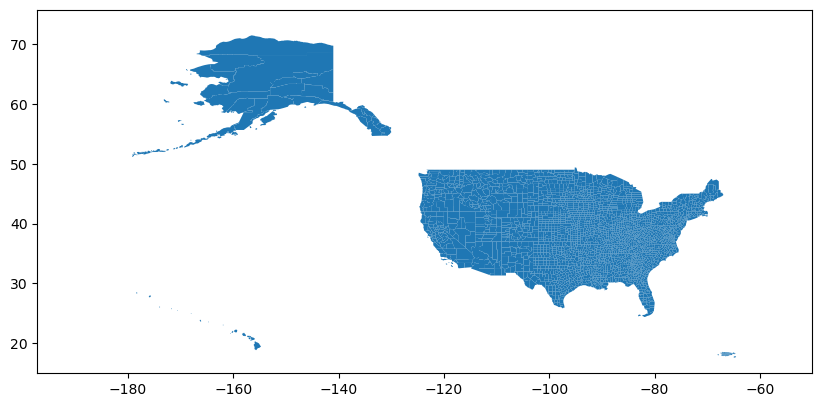

In [60]:
# Plot the gdf polygons
fig, ax = plt.subplots(figsize = (10, 10))
counties.plot(ax = ax)
ax.set_xlim(xmax = -50)
ax.set_ylim(ymin = 15)

plt.show()

Observations on Counties Dataset

The TIGER/Line counties dataset contains 19 columns mixing identifying information, geographic codes, administrative classifications, area measurements, and spatial geometry. Key observations:

- **Data types**: Many numeric fields (STATEFP, COUNTYFP, COUNTYNS, GEOID, LSAD, ALAND, AWATER) are stored as object/string types
- **Geographic scope**: Dataset includes all US counties, territories, and county-equivalents
- **Coordinate system**: Uses NAD83 (EPSG:4269), an unprojected 2D geographic coordinate system for North America
- **Geometry**: Contains polygon geometries for county boundaries

County Cleaning:

- Standardize county names
- filter to include only New York State counties


In [61]:
# Convert column names to lower case
counties.columns = counties.columns.str.lower()

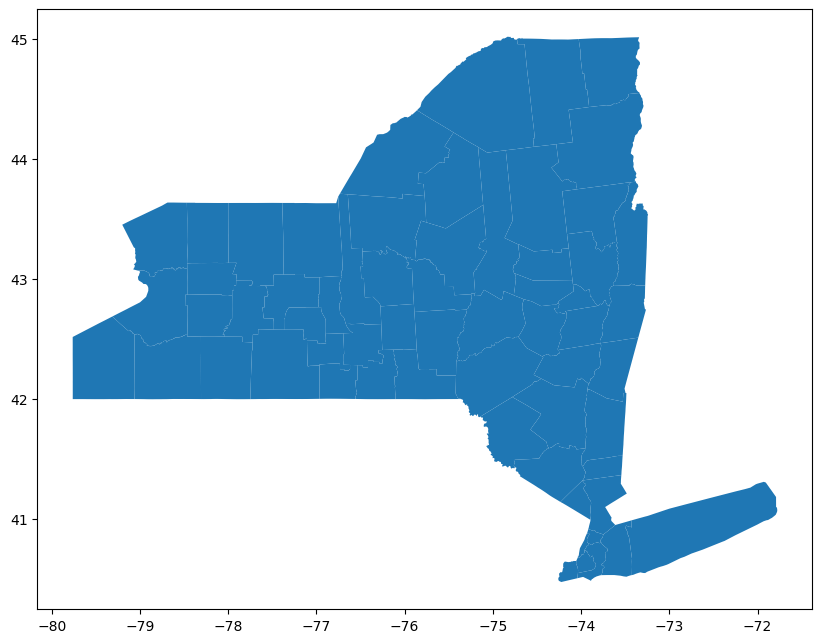

In [62]:
# Filter to counties in ny using its statefp code
ny_counties = counties[counties["statefp"] == '36']

# Plot the gdf polygons
fig, ax = plt.subplots(figsize = (10, 10))
ny_counties.plot(ax = ax)

plt.show()

Prepare for Spatial Join:

- Explore inconsistencies in county names between spills and counties datasets
- Identify names in spills but not in ny_counties
- Handle Tuscarora Nation reservation spill records
- Rename St Lawrence county for consistency
- Rename column so county column names match for spatial join

In [63]:
# Print all unique county names in ny_counties
print(ny_counties['name'].unique())

['Steuben' 'Saratoga' 'Allegany' 'Oswego' 'Ulster' 'St. Lawrence'
 'Schuyler' 'Essex' 'Suffolk' 'Hamilton' 'Dutchess' 'Otsego' 'Tompkins'
 'Albany' 'Cayuga' 'Greene' 'Herkimer' 'Warren' 'Jefferson' 'Clinton'
 'Nassau' 'Madison' 'Washington' 'Westchester' 'Lewis' 'Ontario'
 'Cortland' 'Richmond' 'Erie' 'Putnam' 'Montgomery' 'Sullivan' 'Orleans'
 'Oneida' 'Cattaraugus' 'Yates' 'Tioga' 'Monroe' 'Schoharie' 'Broome'
 'Rensselaer' 'Seneca' 'Queens' 'Genesee' 'Wayne' 'Niagara' 'Kings'
 'Chemung' 'Wyoming' 'New York' 'Columbia' 'Chautauqua' 'Franklin'
 'Onondaga' 'Chenango' 'Fulton' 'Rockland' 'Livingston' 'Delaware'
 'Orange' 'Schenectady' 'Bronx']


In [64]:
# Make a copy of spills_per_county
spills_per_county_c = spills_per_county.copy()

# Examine unique county names in spills_per_county_c
print(spills_per_county_c['county'].unique())

['Albany' 'Allegany' 'Bronx' 'Broome' 'Cattaraugus' 'Cayuga' 'Chautauqua'
 'Chemung' 'Chenango' 'Clinton' 'Columbia' 'Cortland' 'Delaware'
 'Dutchess' 'Erie' 'Essex' 'Franklin' 'Fulton' 'Genesee' 'Greene'
 'Hamilton' 'Herkimer' 'Jefferson' 'Kings' 'Lewis' 'Livingston' 'Madison'
 'Monroe' 'Montgomery' 'Nassau' 'New Jersey - Region 2' 'New York'
 'Niagara' 'Oneida' 'Onondaga' 'Ontario' 'Orange' 'Orleans' 'Oswego'
 'Otsego' 'Putnam' 'Queens' 'Rensselaer' 'Richmond' 'Rockland' 'Saratoga'
 'Schenectady' 'Schoharie' 'Schuyler' 'Seneca' 'St Lawrence' 'Steuben'
 'Suffolk' 'Sullivan' 'Tioga' 'Tompkins' 'Tuscarora Indian Reservation'
 'Ulster' 'Warren' 'Washington' 'Wayne' 'Westchester' 'Wyoming' 'Yates']


In [65]:
# Identify county name differences between spills_per_county_c and ny_counties
diff_names_spills = list(np.setdiff1d(spills_per_county_c['county'].unique(), ny_counties['name'].unique()))

# Return differences
diff_names_spills


['New Jersey - Region 2', 'St Lawrence', 'Tuscarora Indian Reservation']

In [66]:
grader.check("7Ac")

7Ac results: All test cases passed!

In [67]:
diff_names_ny = list(np.setdiff1d(ny_counties['name'].unique(), spills_per_county_c['county'].unique()))
diff_names_ny

['St. Lawrence']

In [68]:
grader.check("7Ad")

7Ad results: All test cases passed!

In [69]:
# Extract the n_spills value for the Tuscarora Indian Reservation from the spills_per_county df
spills_count = spills_per_county_c[spills_per_county_c['county'] == 'Tuscarora Indian Reservation']['n_spills'].values[0]

# Print the number of spills
print(f'Number of spills in the Tuscarora Indian Reservation: {spills_count}')

Number of spills in the Tuscarora Indian Reservation: 1


In [70]:
# Replace 'St Lawrence' with 'St. Lawrence' (rename data frame so final tests still pass)
spills_per_county_c['county'] = spills_per_county_c['county'].replace('St Lawrence', 'St. Lawrence')

# Display unique county names to verify change
spills_per_county_c[spills_per_county_c['county'].str.contains('\.')]

,county,n_spills
50,St. Lawrence,65


In [71]:
# Rename the 'name' column in ny_counties to 'county' to match the spills dataframe for easier merge
ny_counties = ny_counties.rename(columns = {"name": "county"})

Perform Spatial Join:


In [72]:
# Perform inner join on spills_per_county_c and ny_counties
ny_counties = ny_counties.merge(spills_per_county_c,
                               on = 'county',
                               how = 'inner')


Add Tuscarora Indian Reservation spill data to Niagara County since it falls within Niagara County boundaries and doesn't exist as a separate entith in the shapefile

In [73]:
# Add 1 to the number of spills count in Niagara
ny_counties.loc[ny_counties['county'] == 'Niagara', 'n_spills'] += 1


Visualization:

- Create a choropleth map visualizing the number of petroleum spills per county in New York State

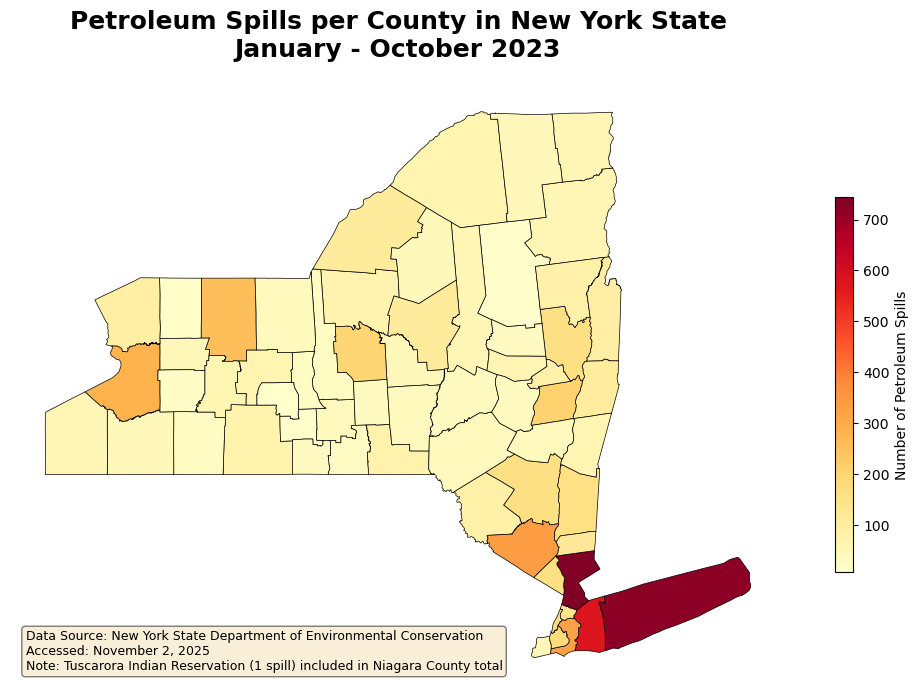

In [74]:
# Create the figure and axis
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Create the choropleth map
ny_counties.plot(
    column = 'n_spills',
    ax = ax,
    legend = True,
    cmap = 'YlOrRd',  # Yellow-Orange-Red colormap
    edgecolor = 'black',
    linewidth = 0.5,
    legend_kwds = {
        'label': 'Number of Petroleum Spills',
        'orientation': 'vertical',
        'shrink': 0.6
    }
)

# Add title
ax.set_title(
    'Petroleum Spills per County in New York State\nJanuary - October 2023',
    fontsize = 18,
    fontweight = 'bold',
    pad = 20
)

# Remove axis
ax.axis('off')

# Add data source annotation
source_text = (
    'Data Source: New York State Department of Environmental Conservation\n'
    'Accessed: November 2, 2025\n'
    'Note: Tuscarora Indian Reservation (1 spill) included in Niagara County total'
)
ax.text(
    0.02, 0.02,
    source_text,
    transform = ax.transAxes,
    fontsize = 9,
    verticalalignment = 'bottom',
    bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
)

# Adjust layout
plt.tight_layout()
plt.show()

In [75]:
# Calculate summary statistics
total_ny_spills = ny_counties['n_spills'].sum()
avg_ny_spills_county = ny_counties['n_spills'].mean()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Total petroleum spills in NY (Jan-Oct 2023): {total_ny_spills}")
print(f"Average spills per county: {avg_ny_spills_county:.1f}")
print(f"Counties with most spills:")
print(ny_counties.nlargest(5, 'n_spills')[['county', 'n_spills']])


Summary Statistics:
Total petroleum spills in NY (Jan-Oct 2023): 7223
Average spills per county: 116.5
Counties with most spills:
         county  n_spills
23  Westchester       744
8       Suffolk       723
20       Nassau       576
59       Orange       336
42       Queens       321


Methodology

This analysis combined incident reporting data from the NYS Department of Environmental Conservation with Census Bureau county boundary geometries. Key data preparation steps included:

1. **Temporal filtering**: Isolated petroleum spills from January 1 - October 31, 2023
2. **Spatial aggregation**: Counted spills by county location
3. **Name standardization**: Reconciled naming inconsistencies between datasets (e.g., "St Lawrence" → "St. Lawrence")
4. **Tribal land handling**: Attributed Tuscarora Indian Reservation spills to the containing county (Niagara)
5. **Geographic filtering**: Removed out-of-state spill records erroneously coded with NY region identifiers

The final merged dataset combined petroleum spill counts with county polygon geometries, enabling the choropleth visualization that reveals clear spatial patterns in spill incidents.

In [76]:
grader.check_all()

7Ac results: All test cases passed!

7Ad results: All test cases passed!

q5d results: All test cases passed!